In [17]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    classification_report
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [18]:
LABEL_NAMES = ["Normal", "Benign", "Malignant"]

def load_labels(path):
    labels = {}
    with open(path) as f:
        for line in f:
            img, lbl = line.strip().split(',')
            labels[img] = int(lbl)
    return labels

with open("bbox_annot.json") as f:
    bbox_data = json.load(f)

In [19]:
def extract_pca_input(img_path, bbox):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        return None

    x1, y1, x2, y2 = bbox
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(img.shape[1], x2), min(img.shape[0], y2)

    roi = img[y1:y2, x1:x2]
    if roi.size == 0:
        return None

    roi = cv2.resize(roi, (64, 64))
    roi = roi.astype(np.float32) / 255.0

    return roi.flatten()

In [20]:
X_raw, y = [], []

labels = load_labels("train.txt")

for img_name, lbl in labels.items():
    if img_name not in bbox_data:
        continue

    img_path = f"imgs/{img_name}"
    if not os.path.exists(img_path):
        continue

    bbox = bbox_data[img_name]["bbs"][0][1]
    features = extract_pca_input(img_path, bbox)

    if features is None:
        continue

    X_raw.append(features)
    y.append(lbl)

X_raw = np.array(X_raw, dtype=np.float32)
y = np.array(y)

print("X_raw shape:", X_raw.shape)
print("y shape:", y.shape)

X_raw shape: (1133, 4096)
y shape: (1133,)


In [21]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)

pca = PCA(n_components=50, random_state=42)
X_train = pca.fit_transform(X_train_raw)
X_test = pca.transform(X_test_raw)

print("Explained variance ratio sum:", np.sum(pca.explained_variance_ratio_))
print("X_train PCA shape:", X_train.shape)
print("X_test PCA shape:", X_test.shape)

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

models = {
    "k-NN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "SVM": make_pipeline(StandardScaler(), SVC(kernel="rbf", probability=True, random_state=42)),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

Explained variance ratio sum: 0.9168813
X_train PCA shape: (906, 50)
X_test PCA shape: (227, 50)



k-NN
              precision    recall  f1-score   support

      Normal       0.96      0.66      0.79        80
      Benign       0.72      0.80      0.76       102
   Malignant       0.38      0.49      0.43        45

    accuracy                           0.69       227
   macro avg       0.69      0.65      0.66       227
weighted avg       0.74      0.69      0.70       227


SVM
              precision    recall  f1-score   support

      Normal       0.96      0.93      0.94        80
      Benign       0.74      0.90      0.81       102
   Malignant       0.54      0.31      0.39        45

    accuracy                           0.79       227
   macro avg       0.75      0.71      0.72       227
weighted avg       0.78      0.79      0.78       227


Decision Tree
              precision    recall  f1-score   support

      Normal       0.90      0.88      0.89        80
      Benign       0.80      0.73      0.76       102
   Malignant       0.44      0.56      0.49      

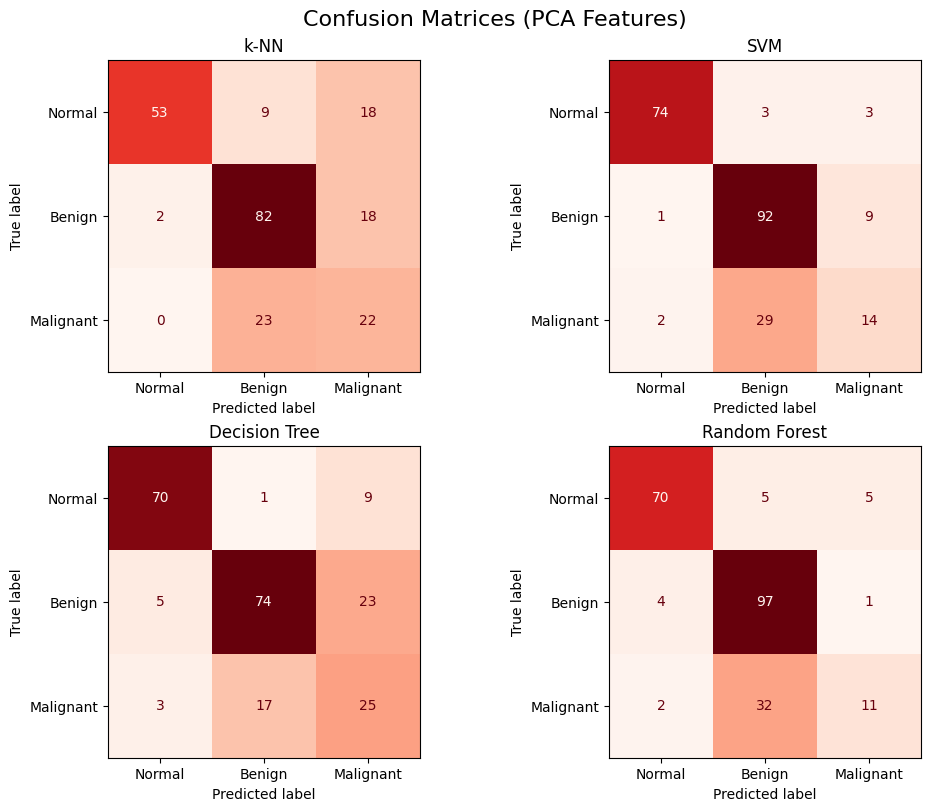

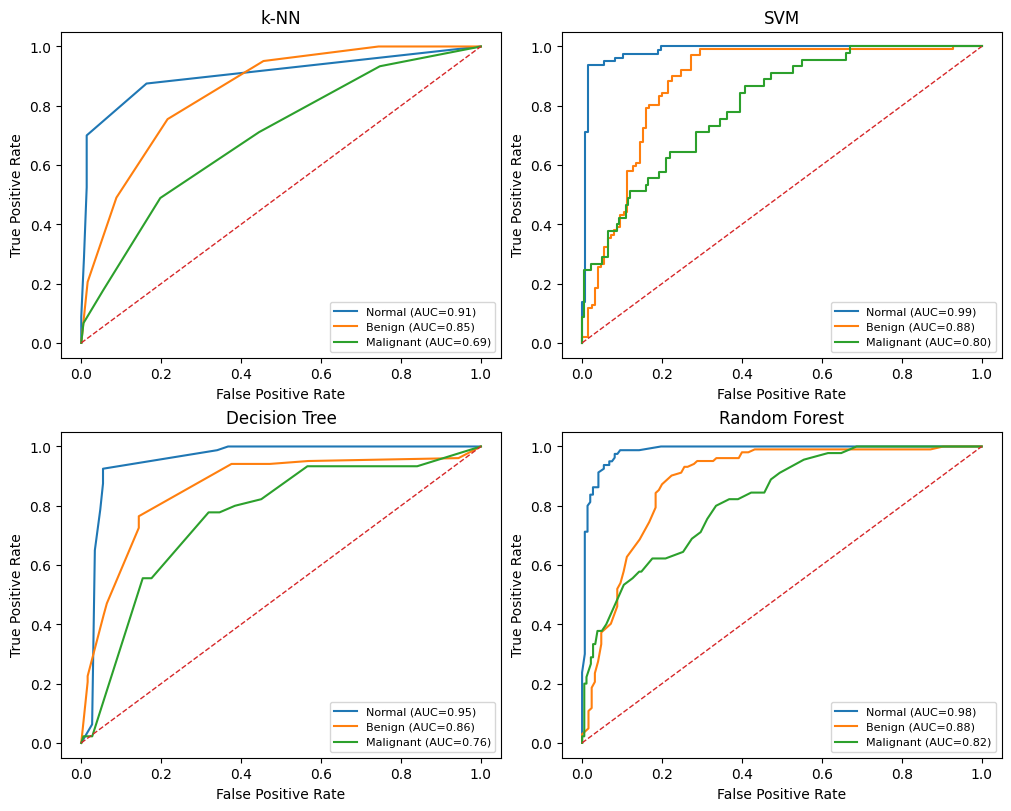

In [22]:
results = []

fig_cm, axes_cm = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
axes_cm = axes_cm.ravel()

fig_roc, axes_roc = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
axes_roc = axes_roc.ravel()

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average="macro", zero_division=0)
    rec = recall_score(y_test, preds, average="macro", zero_division=0)
    f1 = f1_score(y_test, preds, average="macro", zero_division=0)

    results.append([name, acc, prec, rec, f1])

    print(f"\n{name}")
    print(classification_report(y_test, preds, target_names=LABEL_NAMES, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_NAMES)
    disp.plot(ax=axes_cm[i], cmap="Reds", colorbar=False)
    axes_cm[i].set_title(name)

    # ROC Curve
    ax = axes_roc[i]
    for c in range(3):
        fpr, tpr, _ = roc_curve(y_test_bin[:, c], probs[:, c])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{LABEL_NAMES[c]} (AUC={roc_auc:.2f})")

    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=8)

fig_cm.suptitle("Confusion Matrices (PCA Features)", fontsize=16)
plt.show()

fig_roc.suptitle("ROC Curves (PCA Features)", fontsize=16)
plt.show()

In [23]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,k-NN,0.691630,0.687415,0.651770,0.657210
1,SVM,0.792952,0.747145,0.712691,0.717067
2,Decision Tree,0.744493,0.713460,0.718682,0.713053
3,Random Forest,0.784141,0.763997,0.690142,0.691436
